In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

In [21]:
!find "challenge 1" -type f | head -40

challenge 1/daisy/15029936576_8d6f96c72c_n.jpg
challenge 1/daisy/10437929963_bc13eebe0c.jpg
challenge 1/daisy/13953307149_f8de6a768c_m.jpg
challenge 1/daisy/10770585085_4742b9dac3_n.jpg
challenge 1/daisy/18622672908_eab6dc9140_n.jpg
challenge 1/daisy/14471433500_cdaa22e3ea_m.jpg
challenge 1/daisy/18195689904_46619b7e16_n.jpg
challenge 1/daisy/.DS_Store
challenge 1/daisy/14350958832_29bdd3a254.jpg
challenge 1/daisy/14307766919_fac3c37a6b_m.jpg
challenge 1/daisy/10555815624_dc211569b0.jpg
challenge 1/.DS_Store
challenge 1/rose/14943194730_f48b4d4547_n.jpg
challenge 1/rose/12238827553_cf427bfd51_n.jpg
challenge 1/rose/11944957684_2cc806276e.jpg
challenge 1/rose/14145188939_b4de638bd3_n.jpg
challenge 1/rose/14510185271_b5d75dd98e_n.jpg
challenge 1/rose/.DS_Store
challenge 1/rose/14166797345_d2ab9da518.jpg
challenge 1/rose/12338444334_72fcc2fc58_m.jpg
challenge 1/rose/10503217854_e66a804309.jpg
challenge 1/rose/12243068283_ee4c2683e2_n.jpg
challenge 1/rose/14810868100_87eb739f26_m.jpg
chall

In [22]:
!unzip -q challenge\ 1.zip

replace __MACOSX/._challenge 1? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [23]:
IMG_SIZE = 64

image_paths = glob("challenge 1/*/*")

print("Number of paths found:", len(image_paths))
print("First 5 paths:", image_paths[:5])

images = []

for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    images.append(img)

images = np.array(images)

print("Total images loaded:", len(images))
print("Image shape:", images[0].shape)

Number of paths found: 30
First 5 paths: ['challenge 1/daisy/15029936576_8d6f96c72c_n.jpg', 'challenge 1/daisy/10437929963_bc13eebe0c.jpg', 'challenge 1/daisy/13953307149_f8de6a768c_m.jpg', 'challenge 1/daisy/10770585085_4742b9dac3_n.jpg', 'challenge 1/daisy/18622672908_eab6dc9140_n.jpg']
Total images loaded: 30
Image shape: (64, 64, 3)


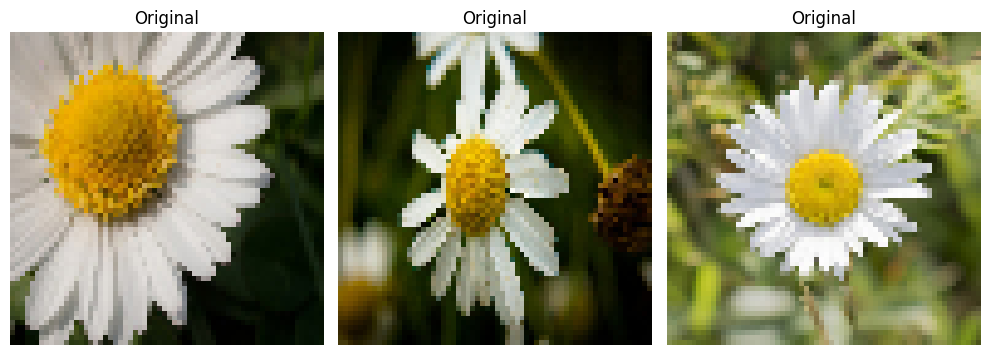

In [24]:
plt.figure(figsize=(10,4))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
def degrade_image(img):
    img_uint8 = (img * 255).astype(np.uint8)

    blurred = cv2.GaussianBlur(img_uint8, (3, 3), 0)

    noise = np.random.normal(0, 5, blurred.shape)
    noisy = blurred + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    return noisy / 255.0

degraded_images = np.array([degrade_image(img) for img in images])

print("Degraded images shape:", degraded_images.shape)

Degraded images shape: (30, 64, 64, 3)


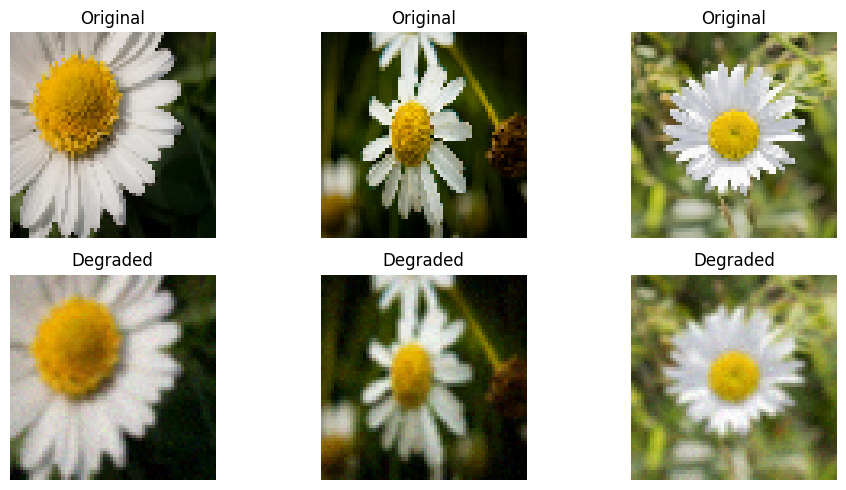

In [26]:
plt.figure(figsize=(10,5))

for i in range(3):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(degraded_images[i])
    plt.title("Degraded")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    degraded_images, images, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (24, 64, 64, 3)
X_test shape: (6, 64, 64, 3)


In [28]:
autoencoder = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

    layers.UpSampling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

    layers.UpSampling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),

    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,579 (439.76 KB)

 Trainable params: 112,579 (439.76 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = autoencoder.fit(
    X_train, y_train,
    epochs=30,
    batch_size=4,
    validation_data=(X_test, y_test)
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - loss: 0.0946 - val_loss: 0.1109
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0824 - val_loss: 0.0868
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0659 - val_loss: 0.0636
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0540 - val_loss: 0.0499
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0432 - val_loss: 0.0480
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0409 - val_loss: 0.0319
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0342 - val_loss: 0.0302
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0327 - val_loss: 0.0282
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0311 - val_loss: 0.0287
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0289 - val_loss: 0.0326
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0322 - val_loss: 0.0288
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0277 - val_loss: 0.0269


In [30]:
repaired_images = autoencoder.predict(X_test)
print("Repaired images shape:", repaired_images.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
Repaired images shape: (6, 64, 64, 3)


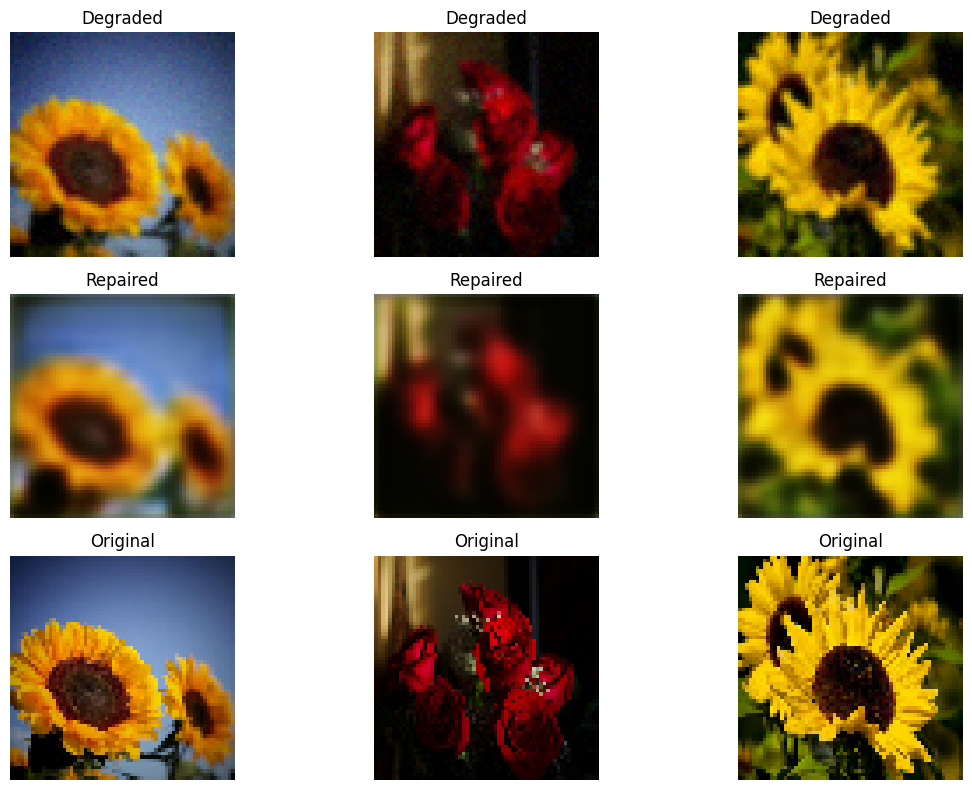

In [31]:
plt.figure(figsize=(12,8))

for i in range(min(3, len(X_test))):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title("Degraded")
    plt.axis("off")

    plt.subplot(3,3,i+4)
    plt.imshow(repaired_images[i])
    plt.title("Repaired")
    plt.axis("off")

    plt.subplot(3,3,i+7)
    plt.imshow(y_test[i])
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
def cartoon_effect(img):
    img_uint8 = (img * 255).astype(np.uint8)

    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)

    edges = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY, 9, 9
    )

    color = cv2.bilateralFilter(img_uint8, 9, 250, 250)
    edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    cartoon = cv2.bitwise_and(color, edges)
    return cartoon / 255.0

stylized_images = np.array([cartoon_effect(img) for img in repaired_images])
print("Stylized images shape:", stylized_images.shape)

Stylized images shape: (6, 64, 64, 3)


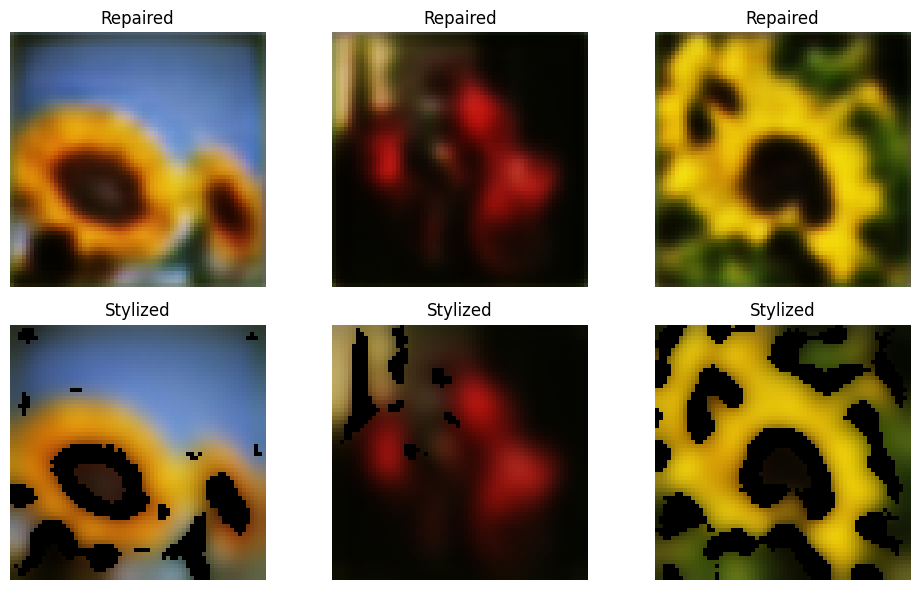

In [33]:
plt.figure(figsize=(10,6))

for i in range(min(3, len(stylized_images))):
    plt.subplot(2,3,i+1)
    plt.imshow(repaired_images[i])
    plt.title("Repaired")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(stylized_images[i])
    plt.title("Stylized")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
import os
os.makedirs("outputs", exist_ok=True)

for i in range(min(3, len(stylized_images))):
    plt.imsave(f"outputs/degraded_{i}.png", X_test[i])
    plt.imsave(f"outputs/repaired_{i}.png", repaired_images[i])
    plt.imsave(f"outputs/stylized_{i}.png", stylized_images[i])

print("Saved images in outputs folder")

Saved images in outputs folder


## Method Explanation

For this challenge, I used a small flower image dataset consisting of 30 images from three classes: daisy, rose, and sunflower.

### Degradation Method
The original images were intentionally degraded using Gaussian blur and mild Gaussian noise.

### Repair Model
A convolutional autoencoder was trained to reconstruct the original clean image from the degraded input.

### Style Transformation
After reconstruction, a cartoon style transformation was applied using OpenCV filters.

### Design Choices
A small balanced subset was used so the workflow could be trained quickly while still producing visually clear results.